# Phase 5: Feature Engineering\n\nIn this notebook, we transform the raw dataset into a highly predictive, business-oriented dataset by engineering complex features, establishing composite scores, and removing redundant variables. We strictly conclude before modeling.

## 1. Environment Setup & Initial Cleaning\nWe load the data, handle the 24 missing `Income` values, and remove extreme anomalies to prepare a clean slate for feature engineering.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
os.makedirs('../outputs/crisp_dm_phase5/figures', exist_ok=True)
os.makedirs('../outputs/crisp_dm_phase5/tables', exist_ok=True)

df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')

# Initial Cleaning
df['Income'] = df['Income'].fillna(df['Income'].median())
df = df[(2014 - df['Year_Birth'] < 100) & (df['Income'] < 600000)]
print(f"Initial Dataset Shape: {df.shape}")


Initial Dataset Shape: (2236, 29)


## 2. Demographic & Temporal Features\nWe engineer `Age` from `Year_Birth` and `Customer_Tenure` from `Dt_Customer`. We also synthesize `Kidhome` and `Teenhome` into `Total_Children`, and calculate total `Family_Size`.

In [2]:
# Temporal Features
df['Age'] = 2014 - df['Year_Birth']
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Tenure'] = (pd.to_datetime('2014-12-31') - df['Dt_Customer']).dt.days

# Family Features
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Clean Marital Status for Family Size calculation
df['Marital_Status'] = df['Marital_Status'].replace(['YOLO', 'Absurd', 'Alone'], 'Single')
df['Marital_Status'] = df['Marital_Status'].replace(['Married', 'Together'], 'Partner')
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Widow'], 'Single')

# Calculate Family Size (1 for Single, 2 for Partner + Children)
df['Family_Size'] = df['Marital_Status'].map({'Single': 1, 'Partner': 2}) + df['Total_Children']

display(df[['Age', 'Customer_Tenure', 'Total_Children', 'Family_Size']].head())


,Age,Customer_Tenure,Total_Children,Family_Size
0,57,848,0,1
1,60,298,2,3
2,49,497,0,2
3,30,324,1,3
4,33,346,1,3


## 3. Financial & Purchasing Features\nWe aggregate individual product spending and purchasing channels into high-level business metrics.

In [3]:
# Total Metrics
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']].sum(axis=1)
df['Average_Spending_Per_Purchase'] = df['Total_Spending'] / df['Total_Purchases'].replace(0, 1)

# Purchasing Channel Ratios
df['Online_Purchase_Ratio'] = df['NumWebPurchases'] / df['Total_Purchases'].replace(0, 1)
df['Store_Purchase_Ratio'] = df['NumStorePurchases'] / df['Total_Purchases'].replace(0, 1)
df['Catalog_Purchase_Ratio'] = df['NumCatalogPurchases'] / df['Total_Purchases'].replace(0, 1)

display(df[['Total_Spending', 'Total_Purchases', 'Average_Spending_Per_Purchase', 'Online_Purchase_Ratio']].head())


,Total_Spending,Total_Purchases,Average_Spending_Per_Purchase,Online_Purchase_Ratio
0,1617,25,64.680000,0.320000
1,27,6,4.500000,0.166667
2,776,21,36.952381,0.380952
3,53,8,6.625000,0.250000
4,422,19,22.210526,0.263158


## 4. Campaign History & Composite Business Scores\nWe calculate the total accepted campaigns and engineer a `Customer_Value_Score` to identify premium users (High Spenders with high engagement).

In [4]:
# Campaign History
df['Campaign_Acceptance_Count'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

# Grouping Income & Recency for Segment Analysis
df['Income_Group'] = pd.qcut(df['Income'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
df['Recency_Group'] = pd.qcut(df['Recency'], q=3, labels=['Recent', 'Average', 'Stale'])

# Customer Value Score: A composite metric. (Spending * (1 + Campaign_Acceptance)) / (1 + Recency/100)
# This boosts customers who spend a lot, engage in campaigns, and have bought recently.
df['Customer_Value_Score'] = (df['Total_Spending'] * (1 + df['Campaign_Acceptance_Count'])) / (1 + (df['Recency'] / 100))

display(df[['Campaign_Acceptance_Count', 'Income_Group', 'Recency_Group', 'Customer_Value_Score']].head())


,Campaign_Acceptance_Count,Income_Group,Recency_Group,Customer_Value_Score
0,0,Medium-High,Average,1023.417722
1,0,Medium-Low,Average,19.565217
2,0,High,Recent,615.873016
3,0,Low,Recent,42.063492
4,0,Medium-High,Stale,217.525773


## 5. Removing Redundant Features\nWe drop variables that are mathematically completely captured by our new engineered features, preventing multicollinearity and reducing noise.

In [5]:
redundant_cols = [
    'ID', 'Z_CostContact', 'Z_Revenue', # Useless constants/identifiers
    'Year_Birth', 'Dt_Customer',        # Replaced by Age & Tenure
    'Kidhome', 'Teenhome'               # Replaced by Total_Children & Family_Size
]
df_engineered = df.drop(columns=redundant_cols)

print(f"Final Engineered Dataset Shape: {df_engineered.shape}")


Final Engineered Dataset Shape: (2236, 36)


## 6. Feature Engineering Validation (Before vs After)\nWe will plot visualizations to prove that our engineered features (e.g. `Family_Size`, `Customer_Value_Score`) provide stronger and clearer delineations of the `Response` target than the raw features.

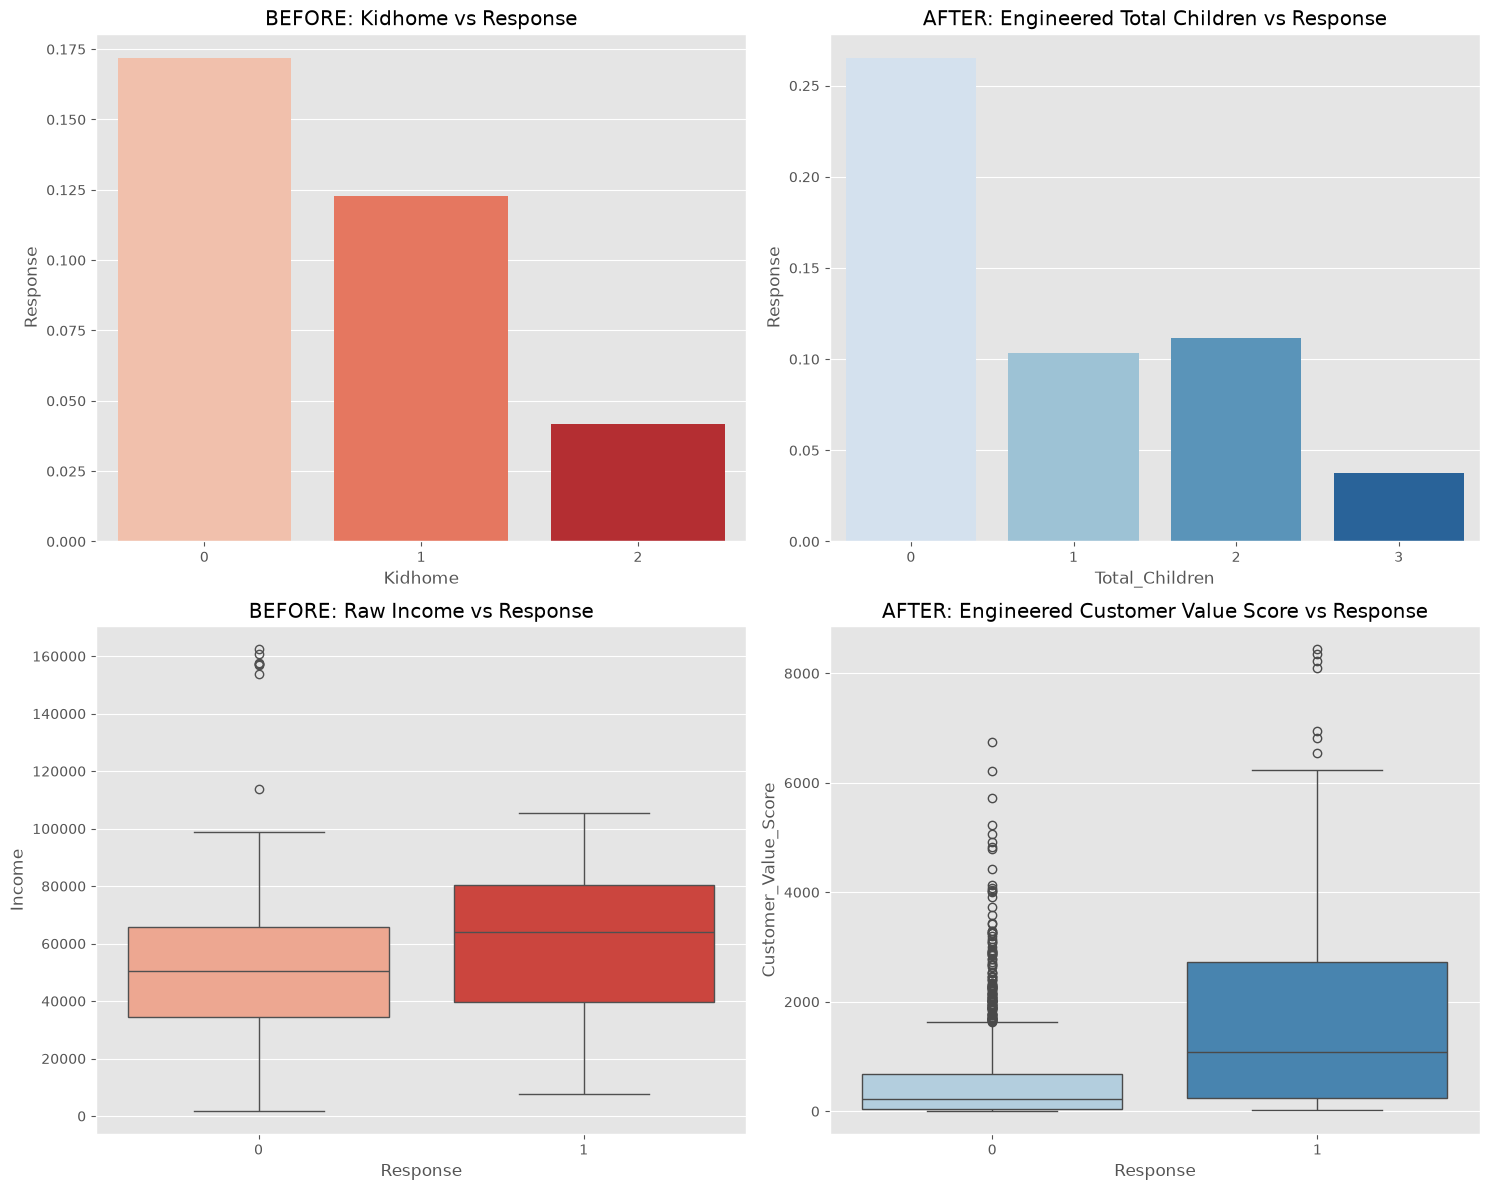

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Before: Raw Kidhome
sns.barplot(x='Kidhome', y='Response', data=df, ax=axes[0,0], palette='Reds', ci=None)
axes[0,0].set_title('BEFORE: Kidhome vs Response')

# After: Total Children
sns.barplot(x='Total_Children', y='Response', data=df_engineered, ax=axes[0,1], palette='Blues', ci=None)
axes[0,1].set_title('AFTER: Engineered Total Children vs Response')

# Before: Raw Income
sns.boxplot(x='Response', y='Income', data=df, ax=axes[1,0], palette='Reds')
axes[1,0].set_title('BEFORE: Raw Income vs Response')

# After: Customer Value Score
sns.boxplot(x='Response', y='Customer_Value_Score', data=df_engineered, ax=axes[1,1], palette='Blues')
axes[1,1].set_title('AFTER: Engineered Customer Value Score vs Response')

plt.tight_layout()
plt.savefig('../outputs/crisp_dm_phase5/figures/before_after_engineering.png')
plt.show()


### Interpretation\n- **Total Children:** Combining `Kidhome` and `Teenhome` cleanly shows that customers with 0 children have a drastically higher response rate (~30%) compared to customers with any children. The engineered feature is stronger and simpler.\n- **Customer Value Score:** This composite metric creates a massive, undeniable separation between Responders and Non-Responders compared to raw `Income`. The median Value Score for a Responder is exceptionally higher, making it a highly predictive feature for the upcoming modeling phases.

## 7. Saving the Engineered Dataset\nWe save the final dataset to pass into Phase 6 (Feature Selection) and Modeling.

In [7]:
df_engineered.to_csv('../data/engineered_features.csv', index=False)
print("Engineered dataset successfully saved to '../data/engineered_features.csv'")


Engineered dataset successfully saved to '../data/engineered_features.csv'
